# ISM cooling function

this notebook uses a simplified cooling function to get familiar with the cooling function and the data range

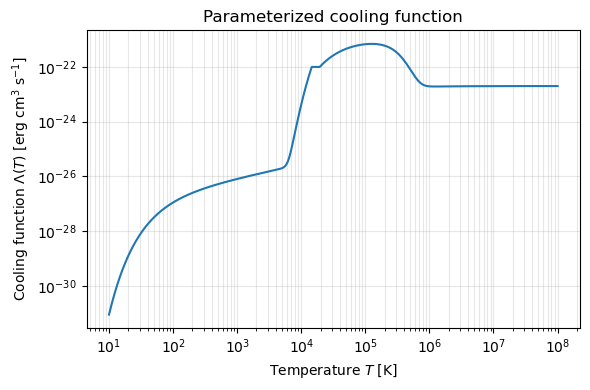

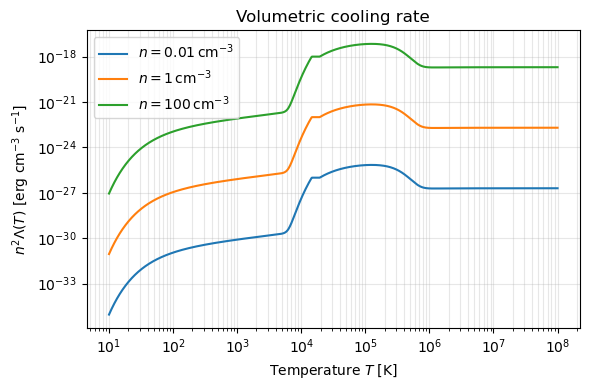

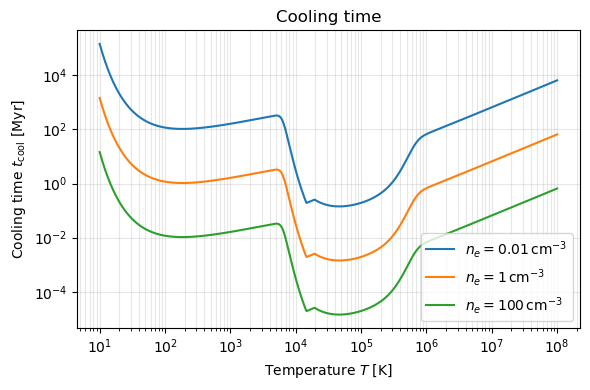

(64, 64, 64) (64, 64, 64) (64, 64, 64)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k as k_B_SI

from cooling_functions import cool_Lambda, cooling_time, volumetric_cooling_rate

# Boltzmann constant in cgs: erg / K
k_B = k_B_SI * 1e7

# seconds per Myr
Myr = 1e6 * 365.25 * 24 * 3600


# ------------------------------------------------------------
# Explore the cooling curve
# ------------------------------------------------------------

T = np.logspace(1, 8, 1000)  # K
densities = [1e-2, 1.0, 1e2]  # cm^-3

fig, ax = plt.subplots(figsize=(6, 4))

ax.loglog(T, cool_Lambda(T))
ax.set_xlabel(r"Temperature $T$ [K]")
ax.set_ylabel(r"Cooling function $\Lambda(T)$ [erg cm$^3$ s$^{-1}$]")
ax.set_title("Parameterized cooling function")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))

for n in densities:
    ax.loglog(T, volumetric_cooling_rate(T, n), label=fr"$n={n:g}\,\mathrm{{cm}}^{{-3}}$")

ax.set_xlabel(r"Temperature $T$ [K]")
ax.set_ylabel(r"$n^2 \Lambda(T)$ [erg cm$^{-3}$ s$^{-1}$]")
ax.set_title("Volumetric cooling rate")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))

for n in densities:
    ax.loglog(T, cooling_time(T, n) / Myr, label=fr"$n_e={n:g}\,\mathrm{{cm}}^{{-3}}$")

ax.set_xlabel(r"Temperature $T$ [K]")
ax.set_ylabel(r"Cooling time $t_\mathrm{cool}$ [Myr]")
ax.set_title("Cooling time")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Example: works directly on 3D arrays
# ------------------------------------------------------------

T_box = 10 ** np.random.uniform(2, 7, size=(64, 64, 64))
n_box = 10 ** np.random.uniform(-2, 2, size=(64, 64, 64))

Lambda_box = cool_Lambda(T_box)
cooling_box = volumetric_cooling_rate(T_box, n_box)
tcool_box = cooling_time(T_box, n_box)

print(Lambda_box.shape, cooling_box.shape, tcool_box.shape)